# Unaligned Evaluation: Profiles and Correct Mode

## Unaligned Evaluation Profiles

In our implementation, **unaligned evaluation** means:

| Profile | Shifts (seconds) | #Points | Purpose |
|---|---|---:|---|
| `--fast` | `0, ±0.1` | 3 | Quick debug check |
| `--coarse` | `0, ±0.1, ±0.2, ±0.5` | 7 | Low-cost robustness check |
| `--wide` | `0, ±0.25, ±0.5, ±1.0, ±1.5, ±2.0, ±3.0, ±4.0, ±5.0` | 17 | Wide-range stress test |
| `--kim_full` | `0, ±0.1, ±0.2, ±0.3, ±0.4, ±0.5, ±1.0, ±1.5, ±2.0, ±2.5` | 19 | Full Kim-style sweep, also our paper |

---

## Why `shifted` mode is the correct evaluation mode

If MIDI score is shifted before inference, then post-processing and scoring must use the **same shifted score timeline**.

### Problem with `reference` mode
`reference` mode (from kim ismir2024) mixes two timelines:
1. Inference uses **shifted** score (`onset/frame`).
2. Post-processing and scoring use **unshifted** score (ground truth `onset/frame`).

This mismatch can make valid model behavior look wrong and can artificially degrade results.

### Correct behavior in `shifted` mode
`shifted` mode keeps one consistent timeline:
1. Inference uses shifted score.
2. Post-processing pick uses shifted onset/frame.
3. Evaluation target is shifted in the same way.

This is internally consistent and musically meaningful.

---

## Practical implication

- `reference` can report overly poor performance under score shift (timeline mismatch effect).
- `shifted` gives a fair measure of how well the model works under that shifted score condition.
- For score-shift experiments in our pipeline, use:

`+exp.unaligned_eval_target=shifted`

---

## After the experiment done, we plot the summary plots


In [1]:
import sys
sys.path.insert(0, "/media/datadisk/home/22828187/zhanh/202602_smc/pytorch")
from pytorch.calculate_scores_unaligned import plot_unaligned_summary_csv

/media/datadisk/home/22828187/conda_env/miniconda3/envs/bark_env/lib/python3.10/site-packages/nnAudio/Spectrogram.py:4: Warning: importing Spectrogram subpackage will be deprecated soon. You should import the feature extractor from the feature subpackage. See actual documentation.
  warnings.warn(


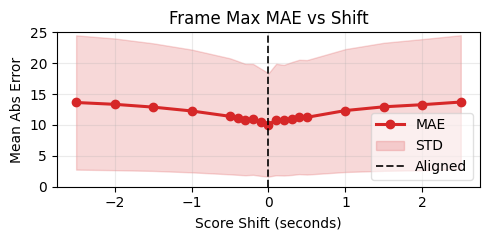

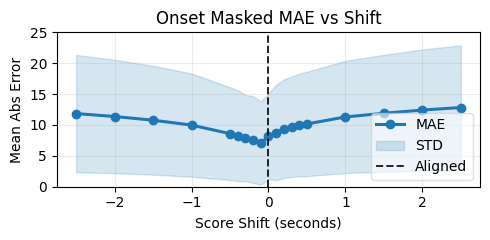

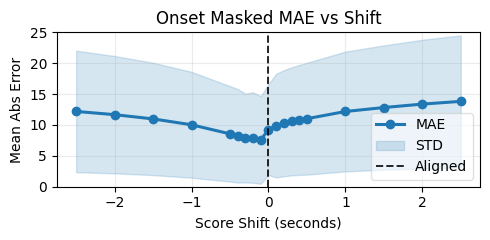

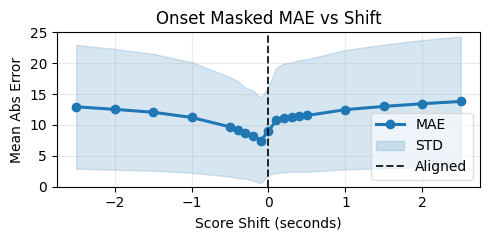

In [5]:
plot_unaligned_summary_csv(csv_path="/media/datadisk/home/22828187/zhanh/202510_hpt_data/workspaces/kim_eval_unaligned/smd/FiLMUNetPretrained+frame/1000000_iterations/FiLMUNetPretrained+frame_smd_unaligned_summary.csv",
    metric="frame_max", color="#d62728", size=(5, 2.5), y_max_axis=25)

plot_unaligned_summary_csv(csv_path="/media/datadisk/home/22828187/zhanh/202510_hpt_data/workspaces/kim_eval_unaligned/smd/hpt+onset+frame+score_note_editor/20000_iterations/hpt+onset+frame+score_note_editor_smd_unaligned_summary.csv",
    metric="onset_masked", color="#1f77b4", size=(5, 2.5), y_max_axis=25)

plot_unaligned_summary_csv(csv_path="/media/datadisk/home/22828187/zhanh/202510_hpt_data/workspaces/kim_eval_unaligned/smd/hppnet+onset+frame+score_note_editor/20000_iterations/hppnet+onset+frame+score_note_editor_smd_unaligned_summary.csv",
    metric="onset_masked", color="#1f77b4", size=(5, 2.5), y_max_axis=25)

plot_unaligned_summary_csv(csv_path="/media/datadisk/home/22828187/zhanh/202510_hpt_data/workspaces/kim_eval_unaligned/smd/dynest+onset+frame+score_note_editor/20000_iterations/dynest+onset+frame+score_note_editor_smd_unaligned_summary.csv",
    metric="onset_masked", color="#1f77b4", size=(5, 2.5), y_max_axis=25)

## Unaligned Test - Experiment run here
1. FiLM-UNet
2. Score-Transformer + HPT / HPPNet / DynEst

In [2]:
%cd /media/datadisk/home/22828187/zhanh/202602_smc
%env PYTHONPATH=/media/datadisk/home/22828187/zhanh/202510_hpt_smc

/media/datadisk/home/22828187/zhanh/202602_smc
env: PYTHONPATH=/media/datadisk/home/22828187/zhanh/202510_hpt_smc


In [5]:
!python pytorch/calculate_scores_unaligned.py --kim_full \
  exp.run_infer=single \
  dataset.test_set=smd \
  model.type=filmunet_pretrained \
  model.kim_condition=frame \
  model.pretrained_checkpoint="/media/datadisk/home/22828187/zhanh/2025_achieve/202602_smc/other repos/kim_ismir2024/pretrained/FiLMUNetPretrained+frame/1000000_iterations.pth" \
  feature.audio_feature=logmel feature.sample_rate=16000 feature.segment_seconds=2.0 feature.hop_seconds=1.0 feature.frames_per_second=100 \
  +exp.unaligned_eval_target=shifted


/media/datadisk/home/22828187/conda_env/miniconda3/envs/bark_env/lib/python3.10/site-packages/nnAudio/Spectrogram.py:4: Warning: importing Spectrogram subpackage will be deprecated soon. You should import the feature extractor from the feature subpackage. See actual documentation.
  warnings.warn(
Evaluation Mode : Kim-style Unaligned (single checkpoint)
Model Name      : FiLMUNetPretrained+frame
Test Set        : smd
Checkpoint      : /media/datadisk/home/22828187/zhanh/2025_achieve/202602_smc/other repos/kim_ismir2024/pretrained/FiLMUNetPretrained+frame/1000000_iterations.pth
Params          : 8797563 (8.798 M)
Shifts (sec)    : [0.0, -0.1, -0.2, -0.3, -0.4, -0.5, -1.0, -1.5, -2.0, -2.5, 0.1, 0.2, 0.3, 0.4, 0.5, 1.0, 1.5, 2.0, 2.5]
Shift Profile   : kim_full
Eval Target     : shifted
Y Max Axis      : None
Kim Unaligned Eval: 100%|█████████████| 50/50 [54:38<00:00, 65.57s/file, shift0_frame_err=10.00]
[done] Wrote summary CSV: /media/datadisk/home/22828187/zhanh/202510_hpt_data/works

In [6]:
!python pytorch/calculate_scores_unaligned.py --kim_full \
  exp.run_infer=single \
  dataset.test_set=smd \
  model.type=hpt \
  score_informed.method=note_editor \
  model.input2=onset model.input3=frame \
  model.pretrained_checkpoint="/media/datadisk/home/22828187/zhanh/202510_hpt_data/workspaces/checkpoints/hpt+onset+frame+score_note_editor/20000_iterations.pth" \
  +exp.unaligned_eval_target=shifted +exp.y_max_axis=25

/media/datadisk/home/22828187/conda_env/miniconda3/envs/bark_env/lib/python3.10/site-packages/nnAudio/Spectrogram.py:4: Warning: importing Spectrogram subpackage will be deprecated soon. You should import the feature extractor from the feature subpackage. See actual documentation.
  warnings.warn(
Evaluation Mode : Kim-style Unaligned (single checkpoint)
Model Name      : hpt+onset+frame+score_note_editor
Test Set        : smd
Checkpoint      : /media/datadisk/home/22828187/zhanh/202510_hpt_data/workspaces/checkpoints/hpt+onset+frame+score_note_editor/20000_iterations.pth
Params          : 5043529 (5.044 M)
Shifts (sec)    : [0.0, -0.1, -0.2, -0.3, -0.4, -0.5, -1.0, -1.5, -2.0, -2.5, 0.1, 0.2, 0.3, 0.4, 0.5, 1.0, 1.5, 2.0, 2.5]
Shift Profile   : kim_full
Eval Target     : shifted
Y Max Axis      : 25.0
Kim Unaligned Eval: 100%|█████████████| 50/50 [32:49<00:00, 39.39s/file, shift0_frame_err=15.70]
[done] Wrote summary CSV: /media/datadisk/home/22828187/zhanh/202510_hpt_data/workspaces/

In [7]:
!python pytorch/calculate_scores_unaligned.py --kim_full \
  exp.run_infer=single \
  dataset.test_set=smd \
  model.type=hppnet \
  score_informed.method=note_editor \
  model.input2=onset model.input3=frame \
  model.pretrained_checkpoint="/media/datadisk/home/22828187/zhanh/202510_hpt_data/workspaces/checkpoints/hppnet+onset+frame+score_note_editor/20000_iterations.pth" \
  +exp.unaligned_eval_target=shifted +exp.y_max_axis=40

/media/datadisk/home/22828187/conda_env/miniconda3/envs/bark_env/lib/python3.10/site-packages/nnAudio/Spectrogram.py:4: Warning: importing Spectrogram subpackage will be deprecated soon. You should import the feature extractor from the feature subpackage. See actual documentation.
  warnings.warn(
Evaluation Mode : Kim-style Unaligned (single checkpoint)
Model Name      : hppnet+onset+frame+score_note_editor
Test Set        : smd
Checkpoint      : /media/datadisk/home/22828187/zhanh/202510_hpt_data/workspaces/checkpoints/hppnet+onset+frame+score_note_editor/20000_iterations.pth
Params          : 1488450 (1.488 M)
Shifts (sec)    : [0.0, -0.1, -0.2, -0.3, -0.4, -0.5, -1.0, -1.5, -2.0, -2.5, 0.1, 0.2, 0.3, 0.4, 0.5, 1.0, 1.5, 2.0, 2.5]
Shift Profile   : kim_full
Eval Target     : shifted
Y Max Axis      : 40.0
Kim Unaligned Eval: 100%|█████████████| 50/50 [24:47<00:00, 29.76s/file, shift0_frame_err=16.67]
[done] Wrote summary CSV: /media/datadisk/home/22828187/zhanh/202510_hpt_data/works

In [3]:
!python pytorch/calculate_scores_unaligned.py --kim_full \
  exp.run_infer=single \
  dataset.test_set=smd \
  model.type=dynest \
  score_informed.method=note_editor \
  model.input2=onset model.input3=frame \
  model.pretrained_checkpoint="/media/datadisk/home/22828187/zhanh/202510_hpt_data/workspaces/checkpoints/dynest+onset+frame+score_note_editor/20000_iterations.pth" \
  +exp.unaligned_eval_target=shifted +exp.y_max_axis=40

/media/datadisk/home/22828187/conda_env/miniconda3/envs/bark_env/lib/python3.10/site-packages/nnAudio/Spectrogram.py:4: Warning: importing Spectrogram subpackage will be deprecated soon. You should import the feature extractor from the feature subpackage. See actual documentation.
  warnings.warn(
Evaluation Mode : Kim-style Unaligned (single checkpoint)
Model Name      : dynest+onset+frame+score_note_editor
Test Set        : smd
Checkpoint      : /media/datadisk/home/22828187/zhanh/202510_hpt_data/workspaces/checkpoints/dynest+onset+frame+score_note_editor/20000_iterations.pth
Params          : 14267481 (14.267 M)
Shifts (sec)    : [0.0, -0.1, -0.2, -0.3, -0.4, -0.5, -1.0, -1.5, -2.0, -2.5, 0.1, 0.2, 0.3, 0.4, 0.5, 1.0, 1.5, 2.0, 2.5]
Shift Profile   : kim_full
Eval Target     : shifted
Y Max Axis      : 40.0
Kim Unaligned Eval: 100%|█████████████| 50/50 [17:35<00:00, 21.11s/file, shift0_frame_err=17.55]
[done] Wrote summary CSV: /media/datadisk/home/22828187/zhanh/202510_hpt_data/wor